# Notebook 1 — EDA & Token Analysis (multilingual-e5-large)

**Goal:** Explore Natural Questions and choose `CHUNK_SIZE` / `CHUNK_OVERLAP` in **tokens**
using the **same tokenizer** as `intfloat/multilingual-e5-large`.

- E5 max context: **512 tokens**
- Default chunk budget: **256 tokens** (answer body), overlap **32 tokens**
- Full passage embedded as: `passage: Question: ...\nAnswer: ...`


In [1]:
import sys, os
sys.path.append(os.path.abspath('..'))

import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

plt.rcParams.update({
    'figure.facecolor': '#0f1117', 'axes.facecolor': '#1a1d27',
    'axes.edgecolor': '#3a3f55', 'axes.labelcolor': '#e0e0e0',
    'xtick.color': '#b0b0b0', 'ytick.color': '#b0b0b0',
    'text.color': '#e0e0e0', 'grid.color': '#2a2f45', 'grid.linestyle': '--', 'grid.alpha': 0.5,
})
ACCENT, ACCENT2, ACCENT3 = '#6366f1', '#22d3ee', '#f59e0b'

from app.config import get_settings
from app.rag.preprocessing import clean_text
from app.rag.tokenizer_utils import (
    get_embedding_tokenizer, count_tokens,
    count_embed_passage_tokens,
)

settings = get_settings()
TOKENIZER = get_embedding_tokenizer(settings.embedding_model)
print('Embedding model :', settings.embedding_model)
print('Vocab size      :', TOKENIZER.vocab_size)
print('Max model tokens:', settings.embedding_max_tokens)
print('chunk_size (tok):', settings.chunk_size, '| overlap:', settings.chunk_overlap)


Embedding model : intfloat/multilingual-e5-large
Vocab size      : 250002
Max model tokens: 512
chunk_size (tok): 384 | overlap: 48


## 1. Load dataset

In [2]:
CSV_PATH = settings.resolve(settings.dataset_path)
df_raw = pd.read_csv(CSV_PATH)
print(f'Shape: {df_raw.shape[0]:,} rows')
print('Columns:', list(df_raw.columns))
df_raw.head(3)


Shape: 86,212 rows
Columns: ['question', 'long_answers', 'short_answers']


,question,long_answers,short_answers
0,which is the most common use of opt-in e-mail ...,A common example of permission marketing is a ...,A newsletter sent to an advertising firm's cus...
1,how i.met your mother who is the mother,"Tracy McConnell, better known as `` The Mother...",Tracy McConnell
2,who had the most wins in the nfl,Active quarterback Tom Brady holds the records...,Tom Brady


## 2. Token lengths — questions & answers

We count tokens with the **E5 tokenizer**, not words or characters.

In [4]:
SAMPLE = min(5000, len(df_raw))
df = df_raw.sample(n=SAMPLE, random_state=42).copy()
df['q']  = df['question'].apply(clean_text)
df['la'] = df['long_answers'].apply(clean_text)
df['sa'] = df['short_answers'].apply(clean_text)

df['q_tok']  = df['q'].apply(lambda t: count_tokens(t, TOKENIZER))
df['la_tok'] = df['la'].apply(lambda t: count_tokens(t, TOKENIZER))
df['sa_tok'] = df['sa'].apply(lambda t: count_tokens(t, TOKENIZER))

df['passage_tok'] = df.apply(
    lambda r: count_embed_passage_tokens(r['q'], r['la'] or r['sa'], TOKENIZER), axis=1
)

df[['q_tok','la_tok','sa_tok','passage_tok']].describe(percentiles=[.25,.5,.75,.9,.95,.99]).round(1)


,q_tok,la_tok,sa_tok,passage_tok
count,5000.0,5000.0,5000.0,5000.0
mean,11.3,133.2,6.8,150.5
std,2.5,86.3,8.8,86.5
min,8.0,3.0,1.0,19.0
25%,10.0,79.0,2.0,96.0
50%,11.0,118.0,4.0,135.0
75%,12.0,169.0,7.0,186.2
90%,14.0,232.0,15.0,249.1
95%,16.0,277.1,24.0,296.1
99%,20.0,400.0,44.0,418.0


## 3. Distribution of answer length (tokens) — basis for chunk_size

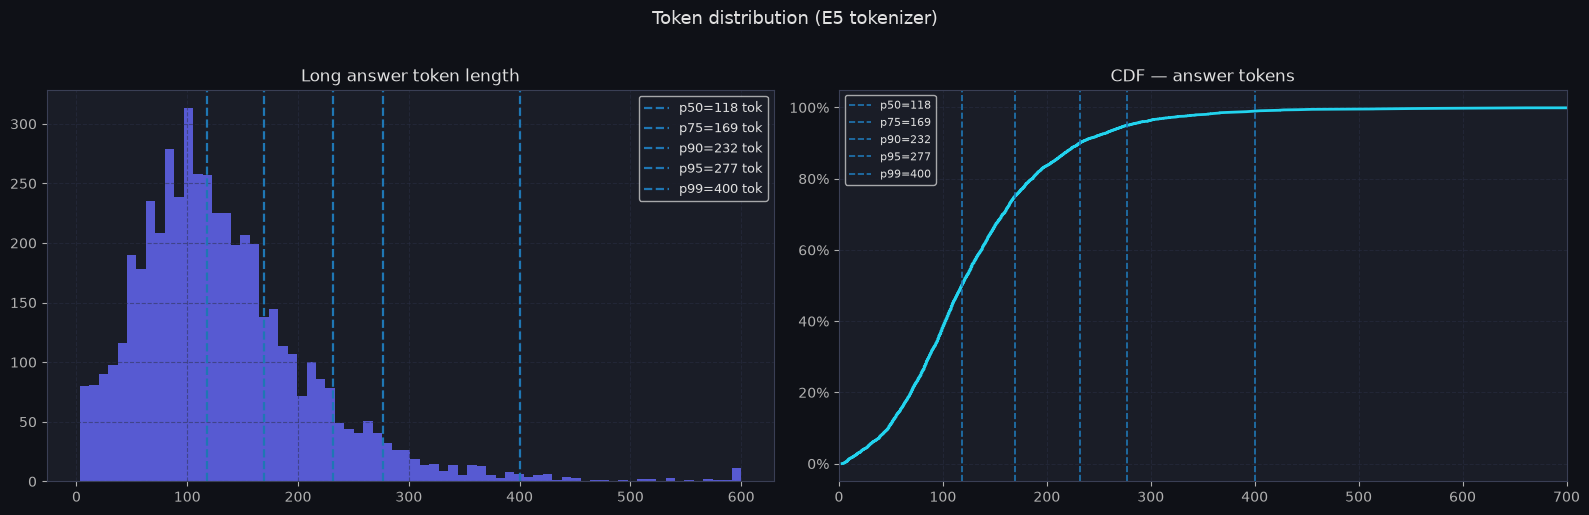

p50: 118 tokens
p75: 169 tokens
p90: 232 tokens
p95: 277 tokens
p99: 400 tokens


In [5]:
la = df['la_tok'].replace(0, np.nan).dropna()
percentiles = {p: np.percentile(la, p) for p in [50, 75, 90, 95, 99]}

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
axes[0].hist(la.clip(upper=600), bins=70, color=ACCENT, edgecolor='none', alpha=0.85)
for p, v in percentiles.items():
    axes[0].axvline(v, lw=1.6, linestyle='--', label=f'p{p}={v:.0f} tok')
axes[0].set_title('Long answer token length'); axes[0].legend(fontsize=9); axes[0].grid(True)

sorted_la = np.sort(la.values)
cdf = np.arange(1, len(sorted_la)+1) / len(sorted_la)
axes[1].plot(sorted_la, cdf, color=ACCENT2, lw=2)
for p, v in percentiles.items():
    axes[1].axvline(v, lw=1.2, linestyle='--', label=f'p{p}={v:.0f}')
axes[1].set_xlim(0, 700); axes[1].set_title('CDF — answer tokens')
axes[1].yaxis.set_major_formatter(mticker.PercentFormatter(1.0))
axes[1].legend(fontsize=8); axes[1].grid(True)
plt.suptitle('Token distribution (E5 tokenizer)', fontsize=13, y=1.02)
plt.tight_layout(); plt.show()

for p, v in percentiles.items():
    print(f'p{p}: {v:.0f} tokens')


## 4. Full passage tokens (must stay ≤ 512)

Passages over 512 tokens: 23 (0.5%)


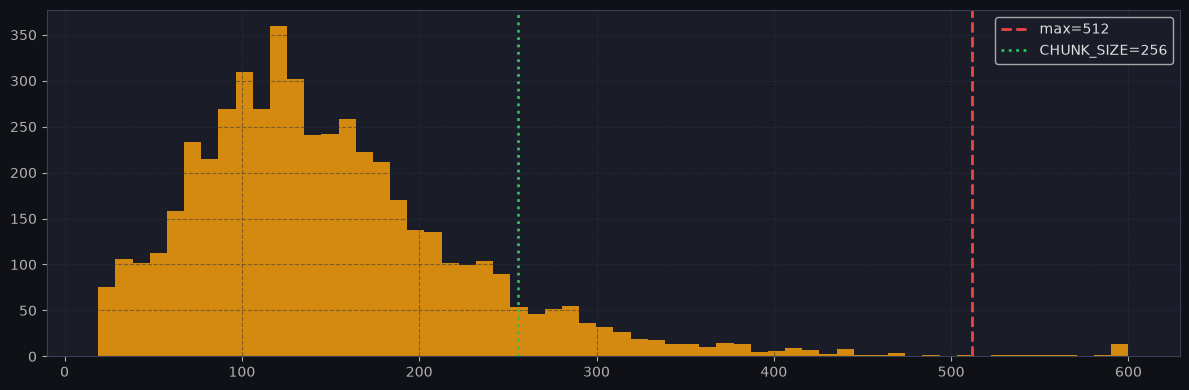

In [6]:
pt = df['passage_tok']
over = (pt > settings.embedding_max_tokens).sum()
print(f'Passages over {settings.embedding_max_tokens} tokens: {over} ({100*over/len(df):.1f}%)')

fig, ax = plt.subplots(figsize=(12, 4), facecolor='#0f1117')
ax.set_facecolor('#1a1d27')
ax.hist(pt.clip(upper=600), bins=60, color=ACCENT3, edgecolor='none', alpha=0.85)
ax.axvline(settings.embedding_max_tokens, color='#ef4444', lw=2, linestyle='--', label=f'max={settings.embedding_max_tokens}')
ax.axvline(settings.chunk_size, color='#22c55e', lw=2, linestyle=':', label=f'CHUNK_SIZE={settings.chunk_size}')
ax.legend(); ax.grid(True); plt.tight_layout(); plt.show()


## 5. Chunk heatmap (token chunk_size × overlap)

overlap_tok,16,32,48,64
chunk_size_tok,,,,
128,1.90,2.05,2.24,2.43
192,1.30,1.32,1.34,1.35
256,1.09,1.10,1.10,1.10
384,1.02,1.02,1.02,1.02
512,1.00,1.00,1.00,1.00


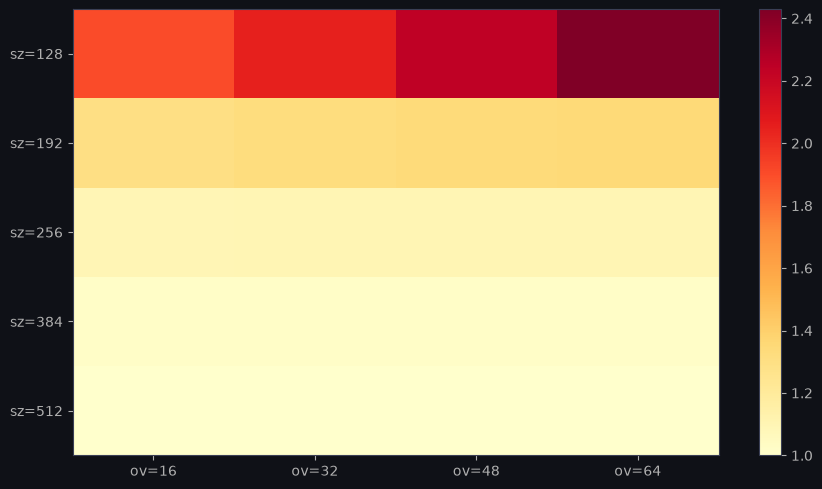

In [7]:
from app.rag.preprocessing import chunk_text
from app.rag.tokenizer_utils import max_answer_tokens_for_question

chunk_sizes = [128, 192, 256, 384, 512]
overlaps = [16, 32, 48, 64]
sample_texts = df['la'].tolist()[:500]
questions = df['q'].tolist()[:500]

rows = []
for cs in chunk_sizes:
    for co in overlaps:
        if co >= cs:
            continue
        total = 0
        for q, t in zip(questions, sample_texts):
            if not t:
                continue
            budget = max_answer_tokens_for_question(q, cs, settings.embedding_max_tokens, TOKENIZER)
            total += len(chunk_text(t, budget, co, tokenizer=TOKENIZER))
        rows.append({'chunk_size_tok': cs, 'overlap_tok': co,
                     'avg_chunks': round(total / max(len(sample_texts), 1), 2)})

res = pd.DataFrame(rows)
pivot = res.pivot(index='chunk_size_tok', columns='overlap_tok', values='avg_chunks')
display(pivot)

fig, ax = plt.subplots(figsize=(9, 5), facecolor='#0f1117')
ax.set_facecolor('#1a1d27')
im = ax.imshow(pivot.values, cmap='YlOrRd', aspect='auto')
ax.set_xticks(range(len(pivot.columns)))
ax.set_yticks(range(len(pivot.index)))
ax.set_xticklabels([f'ov={c}' for c in pivot.columns], color='#b0b0b0')
ax.set_yticklabels([f'sz={r}' for r in pivot.index], color='#b0b0b0')
plt.colorbar(im, ax=ax); plt.tight_layout(); plt.show()


## 6. Recommendation

In [8]:
p50, p90 = np.percentile(la, 50), np.percentile(la, 90)
print('='*58)
print('TOKEN chunk_size guide (E5-large, max 512 tokens)')
print('='*58)
print(f'p50 answer tokens: {p50:.0f} | p90: {p90:.0f}')
print('CHUNK_SIZE=256 + OVERLAP=32  -> recommended default')
print(f'Current: CHUNK_SIZE={settings.chunk_size}, OVERLAP={settings.chunk_overlap}')
print('='*58)


TOKEN chunk_size guide (E5-large, max 512 tokens)
p50 answer tokens: 118 | p90: 232
CHUNK_SIZE=256 + OVERLAP=32  -> recommended default
Current: CHUNK_SIZE=256, OVERLAP=32


## 7. Chars vs tokens — why we use tokens

In [9]:
sample = df['la'].iloc[100]
print(sample[:200], '...')
print('Chars :', len(sample))
print('Tokens:', count_tokens(sample, TOKENIZER))
print('Words :', len(sample.split()))


Acts and the Gospel of Luke make up a two - part work, Luke -- Acts, by the same anonymous author, usually dated to around 80 -- 90 AD. The first part, the Gospel of Luke, tells how God fulfilled his  ...
Chars : 942
Tokens: 240
Words : 165
